In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [2]:
times=data['time'].values/(1e9 * 60); times=times.astype(float);
minutes=1/times[1] #1 / minutes per timestep = timesteps per minute
kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [4]:
#LIMITING Y AXIS
# limit_y=True
limit_y=False

In [5]:
#NEEDED TO PLOT THE CORRECT DATA #*#*
data_type="Tracked_Entrainment_VMF"

In [6]:
#CL VS NONCL

In [7]:
##################################
#PLOTTING
all_cloudbase=1.24

In [8]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"CL_{t}_profile_array_{var}")
#         vars_list.append(f"nonCL_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# input_file = dir3+f"CL_nonCL_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(input_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [11]:
type1='CL';type2='nonCL'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
    # print(key)

In [42]:
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] > 1)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

In [43]:
var_units = [
    ("VMF_C", "VMF_C (kg/m²/s)"),
    ("VMF_G", "VMF_G (kg/m²/s)"),
]

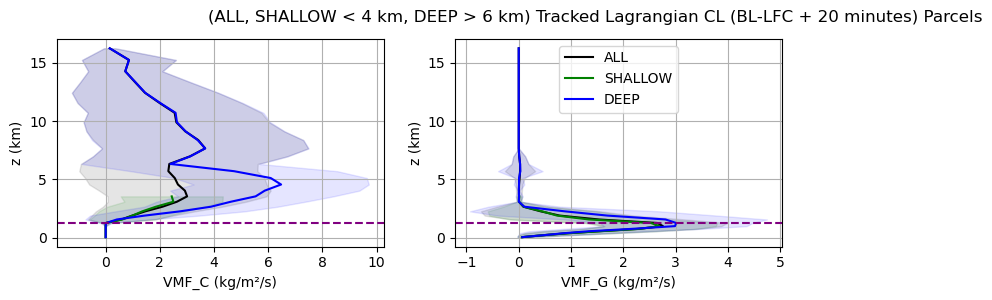

In [45]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"CL_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"CL_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"CL_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"CL_ALL_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"CL_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"CL_DEEP_profile_array_{var.upper()}_SE"].copy(),
        None  # placeholder for xlabel not used in SE
    ))


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        switch=1; factor=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=1; factor=1
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - factor*SE_profile[:,0]*switch, profile[:, 0] + factor*SE_profile[:,0], color=color, alpha=0.1)
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2 = axs
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


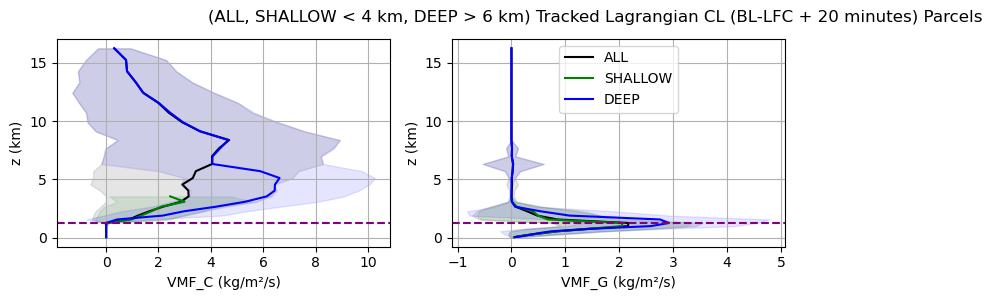

In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonCL_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"nonCL_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonCL_ALL_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"nonCL_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"nonCL_DEEP_profile_array_{var.upper()}_SE"].copy(),
        None  # placeholder for xlabel not used in SE
    ))


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        switch=1; factor=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=1; factor=1
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - factor*SE_profile[:,0]*switch, profile[:, 0] + factor*SE_profile[:,0], color=color, alpha=0.1)
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2 = axs
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [47]:
#DIFFERENCES

def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"CL_{category}_profile_array_{var}"],
            globals()[f"nonCL_{category}_profile_array_{var}"]
        )

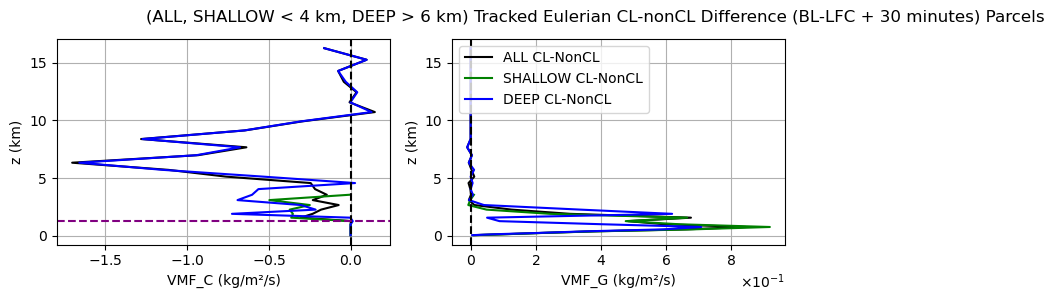

In [48]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]

# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL CL-NonCL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW CL-NonCL')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP CL-NonCL')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    apply_scientific_notation([ax])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian CL-nonCL Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [49]:
#SBZ vs NONSBZ
################################################################

In [50]:
##################################
#PLOTTING

In [51]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []
# SE_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"SBZ_{t}_profile_array_{var}")
#         vars_list.append(f"nonSBZ_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# output_file = dir3+f"SBZ_nonSBZ_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [15]:
type1='SBZ';type2='nonSBZ'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_{type2}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])

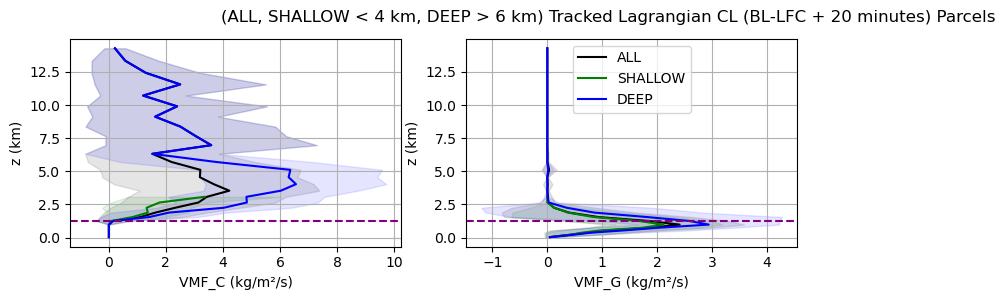

In [54]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"SBZ_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"SBZ_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"SBZ_ALL_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"SBZ_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"SBZ_DEEP_profile_array_{var.upper()}_SE"].copy(),
        None  # placeholder for xlabel not used in SE
    ))


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        switch=1; factor=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=1; factor=1
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - factor*SE_profile[:,0]*switch, profile[:, 0] + factor*SE_profile[:,0], color=color, alpha=0.1)
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2 = axs
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


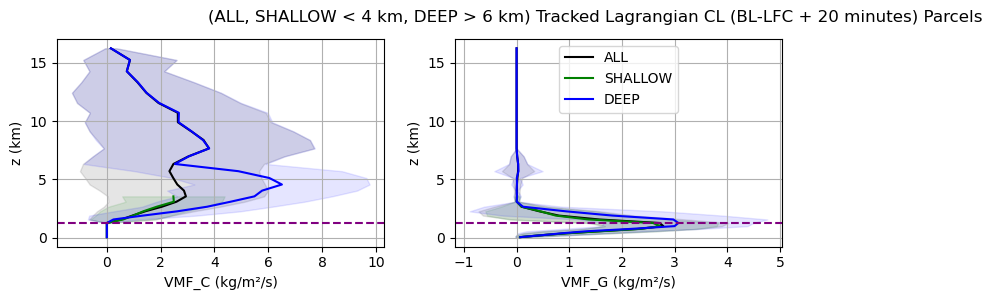

In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"nonSBZ_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"nonSBZ_ALL_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"nonSBZ_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"nonSBZ_DEEP_profile_array_{var.upper()}_SE"].copy(),
        None  # placeholder for xlabel not used in SE
    ))


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        switch=1; factor=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=1; factor=1
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - factor*SE_profile[:,0]*switch, profile[:, 0] + factor*SE_profile[:,0], color=color, alpha=0.1)
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2 = axs
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [56]:
#SBZ vs nonSBZ
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile


var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"nonSBZ_{category}_profile_array_{var}"]
        )

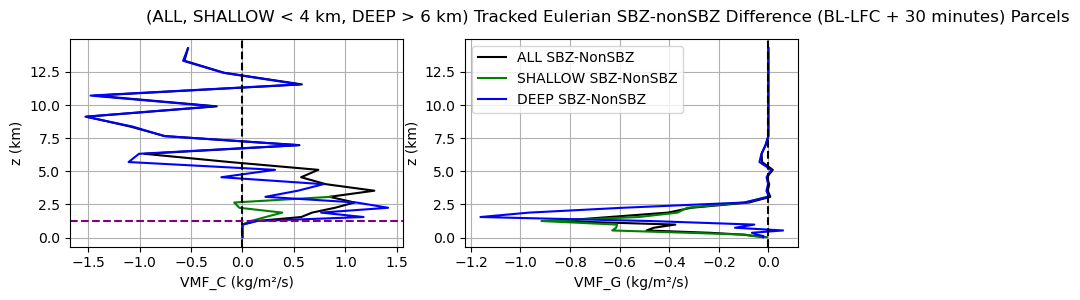

In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-NonSBZ')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-NonSBZ')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-NonSBZ')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')
        
    apply_scientific_notation([ax])

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1=axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-nonSBZ Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()



In [32]:
#ColdPool
################################################################

In [33]:
#PLOTTING
############################################################

In [34]:
# #OLD
# types = ["ALL", "SHALLOW", "DEEP"]
# variables = ["VMF_c","VMF_g"]

# vars_list = []

# for t in types:
#     for var in variables:
#         vars_list.append(f"ColdPool_{t}_profile_array_{var}")

# # Define directory and output file path
# dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
# output_file = dir3 + f"ColdPool_tracked_eulerian_VMF_profiles_{res}_{t_res}_{Np_str}.h5"

# # Open the HDF5 file and read the stored datasets into dynamically named variables
# with h5py.File(output_file, 'r') as f:
#     for var in vars_list:
#         globals()[var] = f[f'{var}'][:]

In [13]:
type1='ColdPool'
dir3=dir+'Project_Algorithms/Tracked_Profiles/OUTPUT_FILES/'
filePath=dir3+f"{data_type}_"+f"{type1}_tracked_profiles_{res}_{t_res}_{Np_str}.h5"
key_list=[]
with h5py.File(filePath, 'r') as h5f:
    for key in h5f.keys():
        globals()[key] = h5f[key][:]
        if '_squares' not in key:
            key_list.append(key)

#CALCULATING STANDARD DEVIATION
for key in key_list:
    # globals()[key+f"_SE"]=ProfileStandardError(globals()[key],globals()[key+f"_squares"])
    globals()[key+f"_SE"]=ProfileStandardDeviation(globals()[key],globals()[key+f"_squares"])
# print(key)

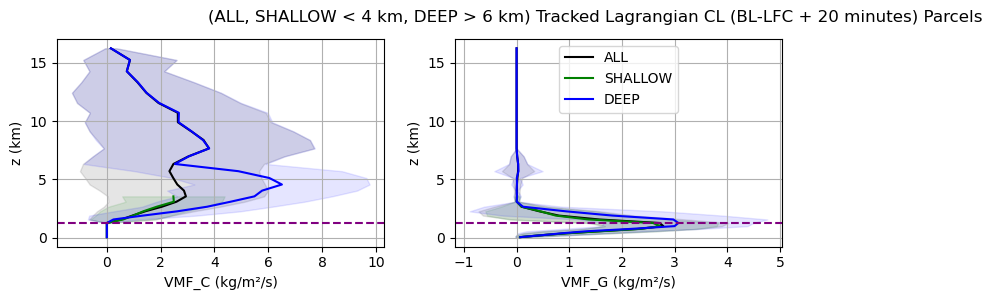

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


profiles = []
SE_profiles = []
for var, label in var_units:
    profiles.append((
        globals()[f"ColdPool_ALL_profile_array_{var.upper()}"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_{var.upper()}"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_{var.upper()}"].copy(),
        label
    ))
    
    SE_profiles.append((
        globals()[f"ColdPool_ALL_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"ColdPool_SHALLOW_profile_array_{var.upper()}_SE"].copy(),
        globals()[f"ColdPool_DEEP_profile_array_{var.upper()}_SE"].copy(),
        None  # placeholder for xlabel not used in SE
    ))


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
# for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
for i, ((ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel), (ALL_SE, SHALLOW_SE, DEEP_SE, _)) in enumerate(zip(profiles, SE_profiles)):
    ax = fig.add_subplot(gs[i])
 
    # Plot Profiles
    profile_list=[ALL_profile_array,SHALLOW_profile_array,DEEP_profile_array]
    SE_profile_list=[ALL_SE,SHALLOW_SE,DEEP_SE]
    colors=['black','green','blue']
    labels=['ALL','SHALLOW','DEEP']
    # for (profile,color,label) in zip(profile_list,colors,labels):   
    for (profile,SE_profile,color,label) in zip(profile_list,SE_profile_list,colors,labels):   
        profile=averaged_profiles(profile) # Compute the averaged profile
        
        
        ################################################
        switch=1; factor=1
        if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
            profile[:,0]*=1000
            SE_profile[:,0]*=1000
            switch=1; factor=1
        #STANDARD ERROR SHADING
        ax.fill_betweenx(profile[:, 1], profile[:, 0] - factor*SE_profile[:,0]*switch, profile[:, 0] + factor*SE_profile[:,0], color=color, alpha=0.1)
        ################################################
        
        ax.plot(profile[:, 0], profile[:, 1],color=color,label=label)
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    #LEGEND
    if i==1:
        ax.legend(loc='upper center')

    if i==6:
        apply_scientific_notation([ax])
        
    #LIMITING YAXIS TO BELOW 3 KM
    if limit_y==True: ax.set_ylim(0,3)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2 = axs
for axis in [ax1,ax2]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
 
#LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian CL (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()

# #MATCHING X AXISES WITH NEXT PLOT
# #(TO KEEP AXISES CONSISTENT RUN PLOTS IN ORDER: 1st Plots, 2nd Plots, 1st Plots)
# for axis in axs:
#     nbins=7;axis.xaxis.set_major_locator(MaxNLocator(nbins=nbins))
# if 'ax8' in globals():
#     fix_x_limits([ax1,ax8])
#     fix_x_limits([ax2,ax9])
#     fix_x_limits([ax3,ax10])
#     fix_x_limits([ax4,ax11])
#     fix_x_limits([ax5,ax12])
#     fix_x_limits([ax6,ax13])
#     fix_x_limits([ax7,ax14])
#     del ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10,ax11,ax12,ax13,ax14


In [60]:
#SBZ vs ColdPool
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

var_names = [var[0] for var in var_units]
for var in var_names:
    for category in ["ALL", "SHALLOW", "DEEP"]:
        globals()[f"{category}_diff_{var}"] = average_difference(
            globals()[f"SBZ_{category}_profile_array_{var}"],
            globals()[f"ColdPool_{category}_profile_array_{var}"]
        )

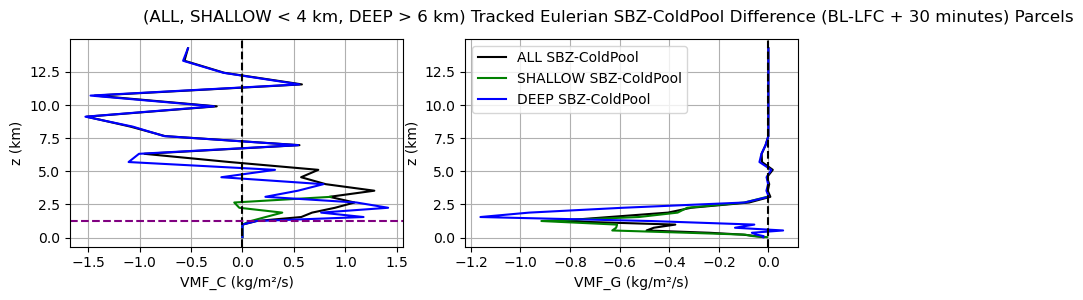

In [61]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

profiles = [
    (
        globals()[f"ALL_diff_{var}"].copy(),
        globals()[f"SHALLOW_diff_{var}"].copy(),
        globals()[f"DEEP_diff_{var}"].copy(),
        label
    )
    for var, label in var_units
]



# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(3, 3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])

    
    # Compute the averaged profile
    ALL_profile = ALL_profile_array.copy()
    SHALLOW_profile = SHALLOW_profile_array.copy()
    DEEP_profile = DEEP_profile_array.copy()

    if xlabel in [r'$q_v$ (g/kg)',r'$q_c+q_i$ (g/kg)','HMC (g/kg/s)']:
        ALL_profile[:,0]*=1000
        SHALLOW_profile[:,0]*=1000
        DEEP_profile[:,0]*=1000
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, 1],color='black',label='ALL SBZ-ColdPool')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, 1],color='green',label='SHALLOW SBZ-ColdPool')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, 1],color='blue',label='DEEP SBZ-ColdPool')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)

    ax.axvline(0,color='k',linestyle='dashed')

    #LEGEND
    if i==1:
        ax.legend(loc='upper left')

    apply_scientific_notation([ax])


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1 = axs[0]
for axis in [ax1]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')
    
# #LEGEND
# legend_ax = fig.add_subplot(gs[1, 2])  # Use the (2, 3) grid slot for the legend
# legend_ax.axis("off")  # Hide axes for the legend box
# legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

#ACCESSORIES
plt.suptitle('(ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Eulerian SBZ-ColdPool Difference (BL-LFC + 30 minutes) Parcels')
plt.tight_layout()

